In [ ]:
import pandas as pd
import re

In [ ]:

dataset = [
    {"id": 1, "text": 'A small startup analyzed the user feedback while the data was incomplete.', "category": 'clean'},
    {"id": 2, "text": 'The government summarized the software update.', "category": 'clean'},
    {"id": 3, "text": 'A local farmer questioned the software update.', "category": 'clean'},
    {"id": 4, "text": 'The doctor explained the annual budget.', "category": 'clean'},
    {"id": 5, "text": 'A local farmer criticized the production schedule while the team worked overtime.', "category": 'clean'},
    {"id": 6, "text": 'The professor evaluated the construction plan while everyone agreed on the plan.', "category": 'clean'},
    {"id": 7, "text": 'My friend evaluated a detailed report.', "category": 'clean'},
    {"id": 8, "text": 'The doctor completed the construction plan.', "category": 'clean'},
    {"id": 9, "text": 'The scientist discussed the construction plan.', "category": 'clean'},
    {"id": 10, "text": 'The scientist explained the financial statement so that everyone agreed on the plan.', "category": 'clean'},
    {"id": 11, "text": 'THE STUDENTS RECOMMENDED THE HEALTH GUIDELINES.', "category": 'near_dup'},
    {"id": 12, "text": "<span style='color:red'>Warning: server maintenance tonight.</span>", "category": 'html'},
    {"id": 13, "text": 'Nope.', "category": 'short'},
    {"id": 14, "text": 'My friend completed a detailed report after the data was incomplete.', "category": 'clean'},
    {"id": 15, "text": 'Our team improved the production schedule.', "category": 'clean'},
    {"id": 16, "text": 'True.', "category": 'short'},
    {"id": 17, "text": "I don't think we're ready for this yet.", "category": 'contraction'},
    {"id": 18, "text": 'Not sure.', "category": 'short'},
    {"id": 19, "text": 'Our team announced the latest results while the system crashed twice.', "category": 'clean'},
    {"id": 20, "text": 'Her brother discussed the production schedule.', "category": 'clean'},
    {"id": 21, "text": 'Her brother supported the research findings before the client requested changes.', "category": 'clean'},
    {"id": 22, "text": 'The company developed the production schedule.', "category": 'clean'},
    {"id": 23, "text": '??? !!! ??? !!!', "category": 'numeric_noise'},
    {"id": 24, "text": 'A young researcher completed the security protocol!', "category": 'near_dup'},
    {"id": 25, "text": 'The teacher developed the user feedback.', "category": 'clean'},
    {"id": 26, "text": 'A small startup designed the security protocol even though the deadline was approaching.', "category": 'clean'},
    {"id": 27, "text": 'The author recommended the academic curriculum even though the client requested changes.', "category": 'clean'},
    {"id": 28, "text": 'THIS IS NOT OKAY AT ALL.', "category": 'mixed_case'},
    {"id": 29, "text": '', "category": 'empty'},
    {"id": 30, "text": 'The research paper, which had been rejected twice before finally being accepted at a minor regional conference after extensive revisions addressing concerns about sample size, methodology, statistical significance, and the generalizability of the findings, was eventually cited by several follow-up studies in subsequent years.', "category": 'long'},
    {"id": 31, "text": 'The committee criticized the new policy so that the system crashed twice.', "category": 'clean'},
    {"id": 32, "text": "You're right, we didn't plan this well.", "category": 'contraction'},
    {"id": 33, "text": 'The doctor explained the software update.', "category": 'exact_dup'},
    {"id": 34, "text": 'A local farmer criticized the marketing strategy!', "category": 'near_dup'},
    {"id": 35, "text": 'The author discussed the construction plan.', "category": 'clean'},
    {"id": 36, "text": 'The athlete reviewed the experimental design.', "category": 'exact_dup'},
    {"id": 37, "text": 'The government tested the health guidelines.', "category": 'clean'},
    {"id": 38, "text": 'The doctor supported the experimental design so that the client requested changes.', "category": 'clean'},
    {"id": 39, "text": 'The musician completed the climate report.', "category": 'exact_dup'},
    {"id": 40, "text": 'THIS IS NOT OKAY AT ALL.', "category": 'mixed_case'},
    {"id": 41, "text": 'I cannot believe this!!!!!!!', "category": 'punctuation_heavy'},
    {"id": 42, "text": 'The board, after several long and exhausting rounds of negotiation that stretched across multiple departments and involved input from engineering, marketing, finance, legal, and customer support teams, finally reached a tentative agreement on the new policy framework, although several members noted that the implementation timeline remained unrealistic given current staffing levels and budget constraints.', "category": 'long'},
    {"id": 43, "text": 'Her brother developed the experimental design.', "category": 'clean'},
    {"id": 44, "text": 'Despite repeated warnings from the safety inspectors, the construction crew continued working through the storm, citing the looming deadline, the penalties for late delivery, the pressure from upper management, and the belief that the structure had already been sufficiently reinforced to withstand the weather conditions expected that week.', "category": 'long'},
    {"id": 45, "text": '===== END OF REPORT =====', "category": 'numeric_noise'},
    {"id": 46, "text": 'Check out this article https://example.com/news/2026/report for more details.', "category": 'url'},
    {"id": 47, "text": 'The committee evaluated the latest results.', "category": 'clean'},
    {"id": 48, "text": 'Thanks @support_team for the quick response! #customerservice', "category": 'mention_hash'},
    {"id": 49, "text": 'The professor supported the financial statement because the budget was limited.', "category": 'clean'},
    {"id": 50, "text": 'Despite repeated warnings from the safety inspectors, the maintenance team continued working through the storm, citing the looming deadline, the penalties for late delivery, the pressure from upper management, and the belief that the structure had already been sufficiently reinforced to withstand the weather conditions expected that week.', "category": 'long'},
    {"id": 51, "text": 'The athlete summarized the research findings.', "category": 'exact_dup'},
    {"id": 52, "text": '<div class="post">Thank you everyone for attending the event!</div>', "category": 'html'},
    {"id": 53, "text": 'The doctor explained the software update while everyone agreed on the plan.', "category": 'clean'},
    {"id": 54, "text": 'After the third round of layoffs in as many years, employees who remained were asked to absorb the responsibilities of their former colleagues, often without additional compensation, training, or even a clear explanation of how their roles had changed within the broader restructuring effort.', "category": 'long'},
    {"id": 55, "text": 'The committee, after several long and exhausting rounds of negotiation that stretched across multiple departments and involved input from engineering, marketing, finance, legal, and customer support teams, finally reached a tentative agreement on the new policy framework, although several members noted that the implementation timeline remained unrealistic given current staffing levels and budget constraints.', "category": 'long'},
    {"id": 56, "text": 'The athlete evaluated the latest results.', "category": 'clean'},
    {"id": 57, "text": 'Sad to see the season end 😢', "category": 'emoji'},
    {"id": 58, "text": 'THE SCIENTIST DISCUSSED THE CONSTRUCTION PLAN.', "category": 'near_dup'},
    {"id": 59, "text": 'Her brother presented the marketing strategy before the system crashed twice.', "category": 'clean'},
    {"id": 60, "text": 'The teacher analyzed the research findings.', "category": 'clean'},
    {"id": 61, "text": 'The committee discussed a detailed report.', "category": 'clean'},
    {"id": 62, "text": '@city_council the new traffic plan is a disaster #traffic #fail', "category": 'mention_hash'},
    {"id": 63, "text": 'The reportâ€™s conclusion was surprisingly optimistic.', "category": 'encoding_glitch'},
    {"id": 64, "text": 'Stop.', "category": 'short'},
    {"id": 65, "text": 'My friend questioned the academic curriculum before the meeting ran long.', "category": 'clean'},
    {"id": 66, "text": 'The children criticized the academic curriculum.', "category": 'clean'},
    {"id": 67, "text": 'A local farmer completed the security protocol since the budget was limited.', "category": 'clean'},
    {"id": 68, "text": 'FINALLY some good news for once', "category": 'mixed_case'},
    {"id": 69, "text": 'This is the best news ever 😍❤️', "category": 'emoji'},
    {"id": 70, "text": 'A small startup recommended the experimental design.', "category": 'clean'},
    {"id": 71, "text": 'Original source: https://news.example.com/world/story123', "category": 'url'},
    {"id": 72, "text": 'Something  is   off  with    this   text.', "category": 'whitespace_issue'},
    {"id": 73, "text": 'The students recommended the health guidelines.', "category": 'clean'},
    {"id": 74, "text": 'The government published the marketing strategy.', "category": 'clean'},
    {"id": 75, "text": 'The university summarized the experimental design while the system crashed twice.', "category": 'clean'},
    {"id": 76, "text": 'The athlete summarized the research findings.', "category": 'exact_dup'},
    {"id": 77, "text": 'The children explained the climate report.', "category": 'clean'},
    {"id": 78, "text": 'The dataset is hosted at http://data.example.org/downloads/dataset.csv', "category": 'url'},
    {"id": 79, "text": 'Are you serious right now...???', "category": 'punctuation_heavy'},
    {"id": 80, "text": 'A young researcher improved the annual budget.', "category": 'clean'},
    {"id": 81, "text": '<b>Important:</b> the meeting has been rescheduled to next week.', "category": 'html'},
    {"id": 82, "text": 'The musician questioned the software update.', "category": 'clean'},
    {"id": 83, "text": 'The students questioned the training program.', "category": 'clean'},
    {"id": 84, "text": 'A small startup reviewed the academic curriculum since the system crashed twice.', "category": 'clean'},
    {"id": 85, "text": 'StOp DoInG tHaT right now', "category": 'mixed_case'},
    {"id": 86, "text": 'WOW just WOW i have no words', "category": 'mixed_case'},
    {"id": 87, "text": 'The scientist recommended a detailed report while the weather was poor.', "category": 'clean'},
    {"id": 88, "text": 'The musician reviewed the academic curriculum even though the system crashed twice.', "category": 'clean'},
    {"id": 89, "text": 'The government designed the health guidelines after the meeting ran long.', "category": 'clean'},
    {"id": 90, "text": ' New policy takes effect Monday. ', "category": 'whitespace_issue'},
    {"id": 91, "text": 'A young researcher recommended the project proposal so that the meeting ran long.', "category": 'clean'},
    {"id": 92, "text": 'No.', "category": 'short'},
    {"id": 93, "text": '@news_channel your coverage of the event was excellent #journalism', "category": 'mention_hash'},
    {"id": 94, "text": 'Source: www.example.com/articles/latest-update', "category": 'url'},
    {"id": 95, "text": 'Sad to see the season end 😢', "category": 'emoji'},
    {"id": 96, "text": 'My friend designed a detailed report.', "category": 'clean'},
    {"id": 97, "text": 'The students published the training program.', "category": 'clean'},
    {"id": 98, "text": 'The government explained the health guidelines so that the results were unexpected.', "category": 'clean'},
    {"id": 99, "text": 'Great talk by @sarah_lee today on #machinelearning and #datascience', "category": 'mention_hash'},
    {"id": 100, "text": 'The children launched the survey data although the system crashed twice.', "category": 'clean'},
    {"id": 101, "text": 'Big congrats to @team_alpha on the win! #championship #proud', "category": 'mention_hash'},
    {"id": 102, "text": 'The engineer presented the marketing strategy.', "category": 'clean'},
    {"id": 103, "text": 'I found this great resource https://blog.example.com/nlp-tips really helpful.', "category": 'url'},
    {"id": 104, "text": 'The professor recommended the production schedule before the meeting ran long.', "category": 'clean'},
    {"id": 105, "text": 'The students launched the training program.', "category": 'clean'},
    {"id": 106, "text": 'Why does this keep happening 😡😡😡', "category": 'emoji'},
    {"id": 107, "text": 'The children designed the health guidelines.', "category": 'exact_dup'},
    {"id": 108, "text": 'The résumé—I mean rÃ©sumÃ©â€”needs to be updated.', "category": 'encoding_glitch'},
    {"id": 109, "text": 'Okay', "category": 'short'},
    {"id": 110, "text": 'The university analyzed the survey data since the team worked overtime.', "category": 'clean'},
    {"id": 111, "text": 'The company presented the safety measures after the meeting ran long.', "category": 'clean'},
    {"id": 112, "text": '  \t  ', "category": 'empty'},
    {"id": 113, "text": 'The children designed the health guidelines.', "category": 'exact_dup'},
    {"id": 114, "text": 'Despite repeated warnings from the safety inspectors, the construction crew continued working through the storm, citing the looming deadline, the penalties for late delivery, the pressure from upper management, and the belief that the structure had already been sufficiently reinforced to withstand the weather conditions expected that week.', "category": 'long'},
    {"id": 115, "text": 'The children discussed the experimental design.', "category": 'clean'},
    {"id": 116, "text": 'The author discussed the construction plan.', "category": 'exact_dup'},
    {"id": 117, "text": 'The musician organized the security protocol.', "category": 'clean'},
    {"id": 118, "text": 'Proud of the whole team today 👏👏', "category": 'emoji'},
    {"id": 119, "text": 'sO confused right NOW about this', "category": 'mixed_case'},
    {"id": 120, "text": 'The students analyzed a detailed report.', "category": 'clean'},
    {"id": 121, "text": 'So tired right now 😴 need coffee ☕', "category": 'emoji'},
    {"id": 122, "text": 'The company tested the safety measures.', "category": 'clean'},
    {"id": 123, "text": 'The doctor developed the experimental design because the weather was poor.', "category": 'clean'},
    {"id": 124, "text": 'The university criticized the software update.', "category": 'clean'},
    {"id": 125, "text": 'The author discussed the construction plan.', "category": 'exact_dup'},
    {"id": 126, "text": "He's been working on this for weeks now.", "category": 'contraction'},
    {"id": 127, "text": "We shouldn't have waited this long to respond.", "category": 'contraction'},
    {"id": 128, "text": 'The company improved the construction plan.', "category": 'clean'},
    {"id": 129, "text": 'Weâ€™ll follow up after the holidayâ€™s end.', "category": 'encoding_glitch'},
    {"id": 130, "text": 'The government questioned the new policy after the budget was limited.', "category": 'clean'},
    {"id": 131, "text": "Can't believe @airline lost my luggage again #travelfail", "category": 'mention_hash'},
    {"id": 132, "text": 'The university designed the latest results although the system crashed twice.', "category": 'clean'},
    {"id": 133, "text": 'We discussed the projectâ€™s timeline in detail.', "category": 'encoding_glitch'},
    {"id": 134, "text": 'The teacher reviewed the academic curriculum although the weather was poor.', "category": 'clean'},
    {"id": 135, "text": 'Full details are available at http://example.org/info.', "category": 'url'},
    {"id": 136, "text": 'Her brother evaluated the software update.', "category": 'clean'},
    {"id": 137, "text": 'The professor recommended the production schedule', "category": 'near_dup'},
    {"id": 138, "text": 'The doctor explained the health guidelines although the budget was limited.', "category": 'clean'},
    {"id": 139, "text": 'After the third round of layoffs in as many years, employees who remained were asked to absorb the responsibilities of their former colleagues, often without additional compensation, training, or even a clear explanation of how their roles had changed within the broader restructuring effort.', "category": 'long'},
    {"id": 140, "text": 'Pricing starts at $19.99 â€” limited time offer.', "category": 'encoding_glitch'},
    {"id": 141, "text": 'The report is available now &nbsp; please review it carefully.', "category": 'html'},
    {"id": 142, "text": 'Wait.', "category": 'short'},
    {"id": 143, "text": 'The athlete improved the training program even though the results were unexpected.', "category": 'clean'},
    {"id": 144, "text": 'False.', "category": 'short'},
    {"id": 145, "text": '<p>The new product launch was a huge success.</p>', "category": 'html'},
    {"id": 146, "text": 'You can register here: https://signup.example.net/form?id=2291', "category": 'url'},
    {"id": 147, "text": 'The company designed the software update after the data was incomplete.', "category": 'clean'},
    {"id": 148, "text": 'The children summarized the research findings.', "category": 'clean'},
    {"id": 149, "text": 'The children criticized the marketing strategy.', "category": 'clean'},
    {"id": 150, "text": 'The teacher discussed the security protocol.', "category": 'clean'},
    {"id": 151, "text": 'N/A N/A N/A N/A', "category": 'numeric_noise'},
    {"id": 152, "text": 'The scientist criticized the health guidelines before the weather was poor.', "category": 'clean'},
    {"id": 153, "text": "We shouldn't have waited this long to respond.", "category": 'contraction'},
    {"id": 154, "text": 'A small startup improved the software update even though the deadline was approaching.', "category": 'clean'},
    {"id": 155, "text": 'Our team presented the health guidelines although the results were unexpected.', "category": 'clean'},
    {"id": 156, "text": 'Our team developed the annual budget.', "category": 'clean'},
    {"id": 157, "text": 'The students organized the production schedule.', "category": 'clean'},
    {"id": 158, "text": 'The scientist launched the health guidelines although the weather was poor.', "category": 'clean'},
    {"id": 159, "text": 'this Is Really Important PLEASE Share', "category": 'mixed_case'},
    {"id": 160, "text": 'The athlete criticized the training program.', "category": 'clean'},
    {"id": 161, "text": 'The scientist recommended the health guidelines.', "category": 'clean'},
    {"id": 162, "text": 'NO NO NO this is completely wrong', "category": 'mixed_case'},
    {"id": 163, "text": 'Multiple    spaces     are      present     here.', "category": 'whitespace_issue'},
    {"id": 164, "text": 'The teacher criticized the health guidelines.', "category": 'clean'},
    {"id": 165, "text": 'Big congrats to @team_alpha on the win! #championship #proud', "category": 'mention_hash'},
    {"id": 166, "text": '', "category": 'empty'},
    {"id": 167, "text": 'See the thread here https://forum.example.com/t/12345 for discussion.', "category": 'url'},
    {"id": 168, "text": "Wouldn't it be easier to just start over?", "category": 'contraction'},
    {"id": 169, "text": 'The athlete summarized the latest results.', "category": 'clean'},
    {"id": 170, "text": 'The committee reviewed the training program.', "category": 'clean'},
    {"id": 171, "text": 'Visit https://example.com for the original announcement.', "category": 'url'},
    {"id": 172, "text": 'The students tested the health guidelines since the team worked overtime.', "category": 'clean'},
    {"id": 173, "text": 'Feeling grateful today 🙏✨', "category": 'emoji'},
    {"id": 174, "text": 'This is the best news ever 😍❤️', "category": 'emoji'},
    {"id": 175, "text": 'The students questioned the annual budget.', "category": 'clean'},
    {"id": 176, "text": 'The scientist summarized the security protocol although the data was incomplete.', "category": 'clean'},
    {"id": 177, "text": '@john_doe just announced the new feature, super excited! #tech #launch', "category": 'mention_hash'},
    {"id": 178, "text": "She isn't going to like this decision at all.", "category": 'contraction'},
    {"id": 179, "text": 'Thanks @support_team for the quick response! #customerservice', "category": 'mention_hash'},
    {"id": 180, "text": "It's not what you'd expect from a report like this.", "category": 'contraction'},
    {"id": 181, "text": 'Just finished the project! 🎉🎉 So relieved 😅', "category": 'emoji'},
    {"id": 182, "text": 'The engineer recommended the software update.', "category": 'clean'},
    {"id": 183, "text": 'The engineer tested the new policy.', "category": 'clean'},
    {"id": 184, "text": 'The professor launched the software update before the meeting ran long.', "category": 'clean'},
    {"id": 185, "text": 'The doctor explained a detailed report.', "category": 'clean'},
    {"id": 186, "text": 'StOp DoInG tHaT right now', "category": 'mixed_case'},
    {"id": 187, "text": "It's not what you'd expect from a report like this.", "category": 'contraction'},
    {"id": 188, "text": 'The children supported the training program.', "category": 'clean'},
    {"id": 189, "text": 'A small startup completed the survey data.', "category": 'clean'},
    {"id": 190, "text": 'The athlete presented the software update while the data was incomplete.', "category": 'clean'},
    {"id": 191, "text": 'The committee supported the new policy.', "category": 'clean'},
    {"id": 192, "text": 'A young researcher improved the experimental design although the team worked overtime.', "category": 'clean'},
    {"id": 193, "text": 'PLEASE READ THIS CAREFULLY before responding', "category": 'mixed_case'},
    {"id": 194, "text": 'The doctor recommended the marketing strategy.', "category": 'clean'},
    {"id": 195, "text": 'The university designed the safety measures.', "category": 'clean'},
    {"id": 196, "text": 'Our team completed the financial statement.', "category": 'clean'},
    {"id": 197, "text": 'Excited for the weekend trip 🏖️☀️', "category": 'emoji'},
    {"id": 198, "text": 'Original source: https://news.example.com/world/story123', "category": 'url'},
    {"id": 199, "text": 'My friend presented the production schedule.', "category": 'clean'},
    {"id": 200, "text": 'The doctor explained a detailed report.', "category": 'exact_dup'},
    {"id": 201, "text": 'HER BROTHER ANALYZED THE ANNUAL BUDGET.', "category": 'near_dup'},
    {"id": 202, "text": 'My friend completed the safety measures.', "category": 'clean'},
    {"id": 203, "text": 'A small startup summarized the survey data.', "category": 'clean'},
    {"id": 204, "text": 'wHaT iS gOiNg On HeRe', "category": 'mixed_case'},
    {"id": 205, "text": 'Our team analyzed the construction plan.', "category": 'clean'},
    {"id": 206, "text": 'The committee announced the software update.', "category": 'clean'},
    {"id": 207, "text": 'A young researcher organized the survey data.', "category": 'clean'},
    {"id": 208, "text": 'The university tested the construction plan.', "category": 'clean'},
    {"id": 209, "text": '<div class="post">Thank you everyone for attending the event!</div>', "category": 'html'},
    {"id": 210, "text": 'The university improved the financial statement after the budget was limited.', "category": 'clean'},
    {"id": 211, "text": 'The athlete reviewed the experimental design.', "category": 'clean'},
    {"id": 212, "text": '$$$ 100% OFF !!! $$$', "category": 'numeric_noise'},
    {"id": 213, "text": 'The engineer analyzed the climate report.', "category": 'clean'},
    {"id": 214, "text": 'The children published the experimental design.', "category": 'clean'},
    {"id": 215, "text": "I don't think we're ready for this yet.", "category": 'contraction'},
    {"id": 216, "text": 'The athlete reviewed a detailed report since everyone agreed on the plan.', "category": 'clean'},
    {"id": 217, "text": 'Why?', "category": 'short'},
    {"id": 218, "text": 'The doctor explained the software update.', "category": 'exact_dup'},
    {"id": 219, "text": 'The students supported the software update.', "category": 'clean'},
    {"id": 220, "text": 'A small startup completed the experimental design.', "category": 'clean'},
    {"id": 221, "text": 'The doctor published the annual budget!', "category": 'near_dup'},
    {"id": 222, "text": 'After the third round of layoffs in as many years, employees who remained were asked to absorb the responsibilities of their former colleagues, often without additional compensation, training, or even a clear explanation of how their roles had changed within the broader restructuring effort.', "category": 'long'},
    {"id": 223, "text": 'The scientist discussed the climate report after the system crashed twice.', "category": 'clean'},
    {"id": 224, "text": 'A small startup summarized the latest results.', "category": 'clean'},
    {"id": 225, "text": '@news_channel your coverage of the event was excellent #journalism', "category": 'mention_hash'},
    {"id": 226, "text": 'The company discussed the financial statement.', "category": 'clean'},
    {"id": 227, "text": 'A small startup tested the climate report.', "category": 'clean'},
    {"id": 228, "text": 'The university tested the financial statement after the deadline was approaching.', "category": 'clean'},
    {"id": 229, "text": 'My friend launched the health guidelines.', "category": 'clean'},
    {"id": 230, "text": 'Visit https://example.com for the original announcement.', "category": 'url'},
    {"id": 231, "text": 'A small startup presented the climate report even though the data was incomplete.', "category": 'clean'},
    {"id": 232, "text": 'The professor completed the software update before the data was incomplete.', "category": 'clean'},
    {"id": 233, "text": 'Please review this section.\t\t', "category": 'whitespace_issue'},
    {"id": 234, "text": '\n  Indented and broken line.\n', "category": 'whitespace_issue'},
    {"id": 235, "text": 'I found this great resource https://blog.example.com/nlp-tips really helpful.', "category": 'url'},
    {"id": 236, "text": 'A young researcher published the project proposal because the deadline was approaching.', "category": 'clean'},
    {"id": 237, "text": 'The musician completed the climate report.', "category": 'exact_dup'},
    {"id": 238, "text": 'The students supported the construction plan before the client requested changes.', "category": 'clean'},
    {"id": 239, "text": 'Wait... what...? How...?', "category": 'punctuation_heavy'},
    {"id": 240, "text": 'A young researcher improved the safety measures.', "category": 'clean'},
    {"id": 241, "text": 'This report needs review.   ', "category": 'whitespace_issue'},
    {"id": 242, "text": 'The students designed the user feedback.', "category": 'clean'},
    {"id": 243, "text": 'A young researcher reviewed the research findings.', "category": 'clean'},
    {"id": 244, "text": 'My friend designed the new policy because the client requested changes.', "category": 'clean'},
    {"id": 245, "text": 'The engineer developed the training program.', "category": 'clean'},
    {"id": 246, "text": 'Got it.', "category": 'short'},
    {"id": 247, "text": 'It costs â‚¬50 for the premium version.', "category": 'encoding_glitch'},
    {"id": 248, "text": 'THE ENGINEER ANALYZED THE MARKETING STRATEGY.', "category": 'near_dup'},
    {"id": 249, "text": 'The doctor published the security protocol.', "category": 'clean'},
    {"id": 250, "text": 'The government presented the research findings while the budget was limited.', "category": 'clean'},
    {"id": 251, "text": 'The company announced the project proposal.', "category": 'clean'},
    {"id": 252, "text": "Really?!?! That's insane!?!", "category": 'punctuation_heavy'},
    {"id": 253, "text": 'A young researcher improved the annual budget.', "category": 'exact_dup'},
    {"id": 254, "text": 'i cant BELIEVE this happened AGAIN', "category": 'mixed_case'},
    {"id": 255, "text": 'The engineer analyzed the marketing strategy.', "category": 'clean'},
    {"id": 256, "text": 'Why does this keep happening 😡😡😡', "category": 'emoji'},
    {"id": 257, "text": 'A local farmer presented the latest results.', "category": 'exact_dup'},
    {"id": 258, "text": "Can't say I'm surprised by the outcome.", "category": 'contraction'},
    {"id": 259, "text": 'A small startup published the survey data.', "category": 'clean'},
    {"id": 260, "text": 'A young researcher improved the annual budget.', "category": 'exact_dup'},
    {"id": 261, "text": "Finally!!! It's done!!! At last!!!", "category": 'punctuation_heavy'},
    {"id": 262, "text": "Can't say I'm surprised by the outcome.", "category": 'contraction'},
    {"id": 263, "text": 'A small startup organized the production schedule.', "category": 'clean'},
    {"id": 264, "text": 'The teacher tested the training program.', "category": 'clean'},
    {"id": 265, "text": 'What is going on here??!!??', "category": 'punctuation_heavy'},
    {"id": 266, "text": 'Our team developed the climate report so that the data was incomplete.', "category": 'clean'},
    {"id": 267, "text": 'A young researcher launched a detailed report while the data was incomplete.', "category": 'clean'},
    {"id": 268, "text": 'Just finished the project! 🎉🎉 So relieved 😅', "category": 'emoji'},
    {"id": 269, "text": '9.99 9.99 9.99 9.99', "category": 'numeric_noise'},
    {"id": 270, "text": 'The committee improved the user feedback.', "category": 'clean'},
    {"id": 271, "text": "Can't stop laughing 😂😂😂 this is too funny", "category": 'emoji'},
    {"id": 272, "text": 'The company designed the marketing strategy.', "category": 'clean'},
    {"id": 273, "text": 'The author analyzed the marketing strategy.', "category": 'clean'},
    {"id": 274, "text": 'The athlete improved the software update.', "category": 'clean'},
    {"id": 275, "text": 'A local farmer summarized the research findings.', "category": 'clean'},
    {"id": 276, "text": 'The committee supported a detailed report.', "category": 'clean'},
    {"id": 277, "text": 'Source: www.example.com/articles/latest-update', "category": 'url'},
    {"id": 278, "text": 'A young researcher designed the security protocol.', "category": 'clean'},
    {"id": 279, "text": 'The report is available now &nbsp; please review it carefully.', "category": 'html'},
    {"id": 280, "text": 'Yes.', "category": 'short'},
    {"id": 281, "text": 'So tired right now 😴 need coffee ☕', "category": 'emoji'},
    {"id": 282, "text": 'A young researcher improved the climate report.', "category": 'clean'},
    {"id": 283, "text": 'The engineer published the safety measures.', "category": 'clean'},
    {"id": 284, "text": 'Loving the new update from @app_official #productivity #win', "category": 'mention_hash'},
    {"id": 285, "text": 'The government evaluated the latest results.', "category": 'exact_dup'},
    {"id": 286, "text": 'Stop. Just stop. Please... stop.', "category": 'punctuation_heavy'},
    {"id": 287, "text": 'My friend questioned the academic curriculum', "category": 'near_dup'},
    {"id": 288, "text": 'The doctor published a detailed report even though the meeting ran long.', "category": 'clean'},
    {"id": 289, "text": 'A local farmer presented the latest results.', "category": 'exact_dup'},
    {"id": 290, "text": 'This update is amazing 🔥🔥🔥', "category": 'emoji'},
    {"id": 291, "text": 'The engineer recommended the survey data.', "category": 'clean'},
    {"id": 292, "text": "Wouldn't it be easier to just start over?", "category": 'contraction'},
    {"id": 293, "text": 'The children announced the academic curriculum.', "category": 'clean'},
    {"id": 294, "text": 'The children designed the health guidelines.', "category": 'clean'},
    {"id": 295, "text": 'The musician evaluated the training program.', "category": 'clean'},
    {"id": 296, "text": 'The students analyzed the research findings.', "category": 'clean'},
    {"id": 297, "text": 'The teacher criticized the project proposal.', "category": 'clean'},
    {"id": 298, "text": 'A local farmer supported a detailed report even though the results were unexpected.', "category": 'clean'},
    {"id": 299, "text": 'The university improved the security protocol after the system crashed twice.', "category": 'clean'},
    {"id": 300, "text": 'Tab\tcharacter\tin\tthe\tmiddle\tof\ttext.', "category": 'whitespace_issue'},
    {"id": 301, "text": 'The engineer tested the health guidelines even though the meeting ran long.', "category": 'clean'},
    {"id": 302, "text": 'The professor analyzed the research findings.', "category": 'clean'},
    {"id": 303, "text": 'The professor launched the security protocol even though the budget was limited.', "category": 'clean'},
    {"id": 304, "text": 'After the third round of layoffs in as many years, employees who remained were asked to absorb the responsibilities of their former colleagues, often without additional compensation, training, or even a clear explanation of how their roles had changed within the broader restructuring effort.', "category": 'long'},
    {"id": 305, "text": "In a sweeping and somewhat rambling statement that touched on everything from quarterly earnings to long-term sustainability goals to recent employee satisfaction surveys, the CEO attempted to reassure investors that the company's strategy remained sound even as competitors continued to gain market share in nearly every major region.", "category": 'long'},
    {"id": 306, "text": 'Her brother analyzed the annual budget even though the system crashed twice.', "category": 'clean'},
    {"id": 307, "text": 'The research paper, which had been rejected twice before finally being accepted at a minor regional conference after extensive revisions addressing concerns about sample size, methodology, statistical significance, and the generalizability of the findings, was eventually cited by several follow-up studies in subsequent years.', "category": 'long'},
    {"id": 308, "text": 'The athlete recommended the production schedule.', "category": 'clean'},
    {"id": 309, "text": 'wHaT iS gOiNg On HeRe', "category": 'mixed_case'},
    {"id": 310, "text": '@john_doe just announced the new feature, super excited! #tech #launch', "category": 'mention_hash'},
    {"id": 311, "text": 'THE MUSICIAN EVALUATED THE TRAINING PROGRAM.', "category": 'near_dup'},
    {"id": 312, "text": 'A small startup announced the experimental design.', "category": 'clean'},
    {"id": 313, "text": 'A small startup presented the latest results while the deadline was approaching.', "category": 'clean'},
    {"id": 314, "text": 'Proud of the whole team today 👏👏', "category": 'emoji'},
    {"id": 315, "text": "Can't stop laughing 😂😂😂 this is too funny", "category": 'emoji'},
    {"id": 316, "text": 'Excited for the weekend trip 🏖️☀️', "category": 'emoji'},
    {"id": 317, "text": 'A local farmer presented the latest results.', "category": 'clean'},
    {"id": 318, "text": 'There  are   too  many   spaces  here.', "category": 'whitespace_issue'},
    {"id": 319, "text": 'Our team organized the annual budget.', "category": 'clean'},
    {"id": 320, "text": 'A young researcher discussed the climate report even though everyone agreed on the plan.', "category": 'clean'},
    {"id": 321, "text": 'Feeling grateful today 🙏✨', "category": 'emoji'},
    {"id": 322, "text": '\t\t', "category": 'empty'},
    {"id": 323, "text": 'The university designed the climate report although the data was incomplete.', "category": 'clean'},
    {"id": 324, "text": '@city_council the new traffic plan is a disaster #traffic #fail', "category": 'mention_hash'},
    {"id": 325, "text": 'The students presented the experimental design.', "category": 'clean'},
    {"id": 326, "text": '<br>New episode out now on all platforms.<br>', "category": 'html'},
    {"id": 327, "text": 'Donâ€™t forget to check the appendix at the end.', "category": 'encoding_glitch'},
    {"id": 328, "text": 'The author criticized the training program.', "category": 'clean'},
    {"id": 329, "text": 'i cant BELIEVE this happened AGAIN', "category": 'mixed_case'},
    {"id": 330, "text": 'The musician launched the survey data.', "category": 'clean'},
    {"id": 331, "text": 'The teacher launched the health guidelines even though the weather was poor.', "category": 'clean'},
    {"id": 332, "text": 'The doctor explained a detailed report.', "category": 'exact_dup'},
    {"id": 333, "text": 'The doctor completed the latest results.', "category": 'clean'},
    {"id": 334, "text": 'The scientist organized the marketing strategy.', "category": 'clean'},
    {"id": 335, "text": 'A young researcher launched the new policy while the client requested changes.', "category": 'clean'},
    {"id": 336, "text": 'The professor completed the research findings.', "category": 'clean'},
    {"id": 337, "text": '12345 67890 00000', "category": 'numeric_noise'},
    {"id": 338, "text": 'The doctor summarized the safety measures before the results were unexpected.', "category": 'clean'},
    {"id": 339, "text": 'The athlete organized the annual budget.', "category": 'clean'},
    {"id": 340, "text": 'The musician launched the project proposal so that the weather was poor.', "category": 'clean'},
    {"id": 341, "text": 'The article said &quot;quality matters most&quot; according to the author.', "category": 'html'},
    {"id": 342, "text": 'The musician presented the annual budget.', "category": 'clean'},
    {"id": 343, "text": 'The musician recommended the marketing strategy even though the budget was limited.', "category": 'clean'},
    {"id": 344, "text": 'Our team improved the user feedback.', "category": 'clean'},
    {"id": 345, "text": 'Why, why, why does this keep happening?!', "category": 'punctuation_heavy'},
    {"id": 346, "text": '  This sentence has leading and trailing spaces.  ', "category": 'whitespace_issue'},
    {"id": 347, "text": 'Loving the new update from @app_official #productivity #win', "category": 'mention_hash'},
    {"id": 348, "text": 'The musician launched the climate report.', "category": 'clean'},
    {"id": 349, "text": 'The teacher published the marketing strategy.', "category": 'clean'},
    {"id": 350, "text": 'The government evaluated the latest results.', "category": 'exact_dup'},
    {"id": 351, "text": 'Our team recommended the financial statement before the data was incomplete.', "category": 'clean'},
    {"id": 352, "text": '\t', "category": 'empty'},
    {"id": 353, "text": 'Sure thing.', "category": 'short'},
    {"id": 354, "text": '#1 #2 #3 #4 #5', "category": 'numeric_noise'},
    {"id": 355, "text": 'The scientist criticized a detailed report although the budget was limited.', "category": 'clean'},
    {"id": 356, "text": "You're right, we didn't plan this well.", "category": 'contraction'},
    {"id": 357, "text": 'A small startup completed the research findings.', "category": 'clean'},
    {"id": 358, "text": 'Our team summarized a detailed report.', "category": 'clean'},
    {"id": 359, "text": 'A small startup developed the financial statement so that the team worked overtime.', "category": 'clean'},
    {"id": 360, "text": '\n', "category": 'empty'},
    {"id": 361, "text": 'This is amazing!!!! Absolutely amazing!!!!', "category": 'punctuation_heavy'},
    {"id": 362, "text": 'The teacher presented the research findings because the team worked overtime.', "category": 'clean'},
    {"id": 363, "text": 'The scientist questioned the financial statement.', "category": 'clean'},
    {"id": 364, "text": 'The engineer designed the academic curriculum.', "category": 'clean'},
    {"id": 365, "text": 'The   results  were  inconclusive.', "category": 'whitespace_issue'},
    {"id": 366, "text": 'The author improved the health guidelines even though the weather was poor.', "category": 'clean'},
    {"id": 367, "text": 'My friend criticized the security protocol.', "category": 'clean'},
    {"id": 368, "text": '   ', "category": 'empty'},
    {"id": 369, "text": "Click <a href='#'>here</a> to download the full document.", "category": 'html'},
    {"id": 370, "text": 'A small startup improved the academic curriculum while the client requested changes.', "category": 'clean'},
    {"id": 371, "text": 'The dataset is hosted at http://data.example.org/downloads/dataset.csv', "category": 'url'},
    {"id": 372, "text": 'The children supported a detailed report.', "category": 'clean'},
    {"id": 373, "text": 'The athlete published the annual budget.', "category": 'clean'},
    {"id": 374, "text": 'The author organized the safety measures.', "category": 'clean'},
    {"id": 375, "text": '<p>The new product launch was a huge success.</p>', "category": 'html'},
    {"id": 376, "text": 'OUR TEAM ORGANIZED THE ANNUAL BUDGET.', "category": 'near_dup'},
    {"id": 377, "text": 'A young researcher completed the security protocol.', "category": 'clean'},
    {"id": 378, "text": 'The university recommended the climate report.', "category": 'clean'},
    {"id": 379, "text": 'The scientist explained the new policy.', "category": 'clean'},
    {"id": 380, "text": 'The athlete summarized the project proposal before the deadline was approaching.', "category": 'clean'},
    {"id": 381, "text": 'v1.0.2-beta.3+build.456', "category": 'numeric_noise'},
    {"id": 382, "text": 'The scientist reviewed the latest results.', "category": 'clean'},
    {"id": 383, "text": 'Our team presented the health guidelines!', "category": 'near_dup'},
    {"id": 384, "text": 'The children analyzed the climate report before the results were unexpected.', "category": 'clean'},
    {"id": 385, "text": 'The company published the annual budget.', "category": 'clean'},
    {"id": 386, "text": 'The doctor organized the new policy.', "category": 'clean'},
    {"id": 387, "text": 'Check out our latest update &amp; improvements here.', "category": 'html'},
    {"id": 388, "text": "He's been working on this for weeks now.", "category": 'contraction'},
    {"id": 389, "text": 'A small startup completed the health guidelines because the system crashed twice.', "category": 'clean'},
    {"id": 390, "text": 'The teacher explained the academic curriculum so that the data was incomplete.', "category": 'clean'},
    {"id": 391, "text": 'A local farmer announced the new policy since the client requested changes.', "category": 'clean'},
    {"id": 392, "text": 'The teacher completed the financial statement although the results were unexpected.', "category": 'clean'},
    {"id": 393, "text": "They've already finished the work, haven't they?", "category": 'contraction'},
    {"id": 394, "text": 'After the third round of layoffs in as many years, employees who remained were asked to absorb the responsibilities of their former colleagues, often without additional compensation, training, or even a clear explanation of how their roles had changed within the broader restructuring effort.', "category": 'long'},
    {"id": 395, "text": 'Her brother summarized the user feedback.', "category": 'clean'},
    {"id": 396, "text": 'The professor questioned the academic curriculum.', "category": 'clean'},
    {"id": 397, "text": 'Read more &raquo; about our new policy changes.', "category": 'html'},
    {"id": 398, "text": 'The government evaluated the latest results.', "category": 'clean'},
    {"id": 399, "text": 'More info at https://example.com/docs/v2/readme.', "category": 'url'},
    {"id": 400, "text": '   ', "category": 'empty'},
    {"id": 401, "text": 'The teacher published the financial statement.', "category": 'clean'},
    {"id": 402, "text": 'A small startup discussed the project proposal.', "category": 'clean'},
    {"id": 403, "text": 'Our team organized the user feedback.', "category": 'clean'},
    {"id": 404, "text": 'The musician completed the climate report.', "category": 'clean'},
    {"id": 405, "text": 'The professor discussed the safety measures.', "category": 'clean'},
    {"id": 406, "text": 'The government improved the financial statement before the budget was limited.', "category": 'clean'},
    {"id": 407, "text": 'The company analyzed the academic curriculum.', "category": 'clean'},
    {"id": 408, "text": 'Her brother developed the production schedule after the meeting ran long.', "category": 'clean'},
    {"id": 409, "text": 'See the thread here https://forum.example.com/t/12345 for discussion.', "category": 'url'},
    {"id": 410, "text": 'After the third round of layoffs in as many years, employees who remained were asked to absorb the responsibilities of their former colleagues, often without additional compensation, training, or even a clear explanation of how their roles had changed within the broader restructuring effort.', "category": 'long'},
    {"id": 411, "text": 'The athlete questioned the software update.', "category": 'clean'},
    {"id": 412, "text": '<b>Important:</b> the meeting has been rescheduled to next week.', "category": 'html'},
    {"id": 413, "text": 'The teacher tested the construction plan.', "category": 'clean'},
    {"id": 414, "text": 'The cafÃ© was absolutely wonderful â€“ great coffee!', "category": 'encoding_glitch'},
    {"id": 415, "text": 'The government reviewed the research findings since the system crashed twice.', "category": 'clean'},
    {"id": 416, "text": 'The author presented the marketing strategy so that everyone agreed on the plan.', "category": 'clean'},
    {"id": 417, "text": 'My friend developed the new policy.', "category": 'clean'},
    {"id": 418, "text": 'The author explained the health guidelines.', "category": 'clean'},
    {"id": 419, "text": 'The doctor designed the construction plan.', "category": 'clean'},
    {"id": 420, "text": '  The meeting starts at 10am.', "category": 'whitespace_issue'},
    {"id": 421, "text": 'The musician summarized the experimental design since the budget was limited.', "category": 'clean'},
    {"id": 422, "text": 'Shoutout to @local_bakery for the best bread in town #foodie', "category": 'mention_hash'},
    {"id": 423, "text": 'The author developed the experimental design.', "category": 'clean'},
    {"id": 424, "text": 'The professor recommended the latest results while the team worked overtime.', "category": 'clean'},
    {"id": 425, "text": 'Her brother reviewed the project proposal.', "category": 'clean'},
    {"id": 426, "text": 'The committee questioned the annual budget.', "category": 'clean'},
    {"id": 427, "text": 'PLEASE READ THIS CAREFULLY before responding', "category": 'mixed_case'},
    {"id": 428, "text": 'Our team tested the project proposal.', "category": 'clean'},
    {"id": 429, "text": 'A young researcher developed the construction plan.', "category": 'clean'},
    {"id": 430, "text": 'The university discussed the security protocol.', "category": 'clean'},
    {"id": 431, "text": "I'm sure they'll figure it out eventually.", "category": 'contraction'},
    {"id": 432, "text": 'The author developed the new policy.', "category": 'clean'},
    {"id": 433, "text": 'The doctor analyzed the academic curriculum.', "category": 'clean'},
    {"id": 434, "text": 'OUR TEAM COMPLETED THE FINANCIAL STATEMENT.', "category": 'near_dup'},
    {"id": 435, "text": 'A young researcher improved the research findings.', "category": 'clean'},
    {"id": 436, "text": 'No way!!! No way!!! No way!!!', "category": 'punctuation_heavy'},
    {"id": 437, "text": '', "category": 'empty'},
    {"id": 438, "text": 'Check out our latest update &amp; improvements here.', "category": 'html'},
    {"id": 439, "text": 'Our team evaluated a detailed report.', "category": 'clean'},
    {"id": 440, "text": 'The children analyzed the experimental design even though the results were unexpected.', "category": 'clean'},
    {"id": 441, "text": 'Full details are available at http://example.org/info.', "category": 'url'},
    {"id": 442, "text": "She isn't going to like this decision at all.", "category": 'contraction'},
    {"id": 443, "text": 'Itâ€™s unclear whether the results are significant.', "category": 'encoding_glitch'},
    {"id": 444, "text": 'The students recommended the annual budget while everyone agreed on the plan.', "category": 'clean'},
    {"id": 445, "text": 'The documentâ€™s formatting got messed up during export.', "category": 'encoding_glitch'},
    {"id": 446, "text": 'Check out this article https://example.com/news/2026/report for more details.', "category": 'url'},
    {"id": 447, "text": 'Her brother supported the software update although the meeting ran long.', "category": 'clean'},
    {"id": 448, "text": "In a sweeping and somewhat rambling statement that touched on everything from quarterly earnings to long-term sustainability goals to recent employee satisfaction surveys, the CEO attempted to reassure investors that the company's strategy remained sound even as competitors continued to gain market share in nearly every major region.", "category": 'long'},
    {"id": 449, "text": '\tThe budget was approved yesterday.', "category": 'whitespace_issue'},
    {"id": 450, "text": 'A local farmer evaluated the academic curriculum.', "category": 'clean'},
    {"id": 451, "text": 'A small startup explained the safety measures.', "category": 'clean'},
    {"id": 452, "text": 'Her brother questioned the safety measures.', "category": 'clean'},
    {"id": 453, "text": 'More info at https://example.com/docs/v2/readme.', "category": 'url'},
    {"id": 454, "text": 'Our team presented the survey data.', "category": 'clean'},
    {"id": 455, "text": 'The children criticized the new policy.', "category": 'clean'},
    {"id": 456, "text": 'Her brother designed the latest results.', "category": 'clean'},
    {"id": 457, "text": '@manager can we move the meeting? #scheduling #worklife', "category": 'mention_hash'},
    {"id": 458, "text": '1 2 3 4 5 6 7 8 9 10', "category": 'numeric_noise'},
    {"id": 459, "text": 'This update is amazing 🔥🔥🔥', "category": 'emoji'},
    {"id": 460, "text": 'A young researcher launched the security protocol.', "category": 'clean'},
    {"id": 461, "text": 'My friend published the survey data.', "category": 'clean'},
    {"id": 462, "text": 'Maybe later.', "category": 'short'},
    {"id": 463, "text": 'The athlete published the training program while the team worked overtime.', "category": 'clean'},
    {"id": 464, "text": 'The professor organized the annual budget.', "category": 'clean'},
    {"id": 465, "text": 'The athlete reviewed the experimental design.', "category": 'exact_dup'},
    {"id": 466, "text": 'You can register here: https://signup.example.net/form?id=2291', "category": 'url'},
    {"id": 467, "text": 'Shoutout to @local_bakery for the best bread in town #foodie', "category": 'mention_hash'},
    {"id": 468, "text": 'The committee improved the project proposal.', "category": 'clean'},
    {"id": 469, "text": "I'm sure they'll figure it out eventually.", "category": 'contraction'},
    {"id": 470, "text": 'The teacher completed a detailed report.', "category": 'clean'},
    {"id": 471, "text": 'My friend summarized the experimental design.', "category": 'clean'},
    {"id": 472, "text": 'The athlete summarized the research findings because the client requested changes.', "category": 'clean'},
    {"id": 473, "text": 'Really?', "category": 'short'},
    {"id": 474, "text": 'The government reviewed the training program.', "category": 'clean'},
    {"id": 475, "text": 'Great talk by @sarah_lee today on #machinelearning and #datascience', "category": 'mention_hash'},
    {"id": 476, "text": "They've already finished the work, haven't they?", "category": 'contraction'},
    {"id": 477, "text": 'A young researcher presented the climate report even though the system crashed twice.', "category": 'clean'},
    {"id": 478, "text": 'The author developed the climate report even though the meeting ran long.', "category": 'clean'},
    {"id": 479, "text": 'The doctor published the annual budget.', "category": 'clean'},
    {"id": 480, "text": 'The professor analyzed the latest results.', "category": 'clean'},
    {"id": 481, "text": 'HER BROTHER REVIEWED THE PROJECT PROPOSAL.', "category": 'near_dup'},
    {"id": 482, "text": 'The engineer evaluated the marketing strategy.', "category": 'clean'},
    {"id": 483, "text": 'The athlete designed the construction plan.', "category": 'clean'},
    {"id": 484, "text": 'The seminar covered naÃ¯ve Bayes and other classifiers.', "category": 'encoding_glitch'},
    {"id": 485, "text": 'Hmm.', "category": 'short'},
    {"id": 486, "text": 'Our team announced the production schedule.', "category": 'clean'},
    {"id": 487, "text": '', "category": 'empty'},
    {"id": 488, "text": '----------------------', "category": 'numeric_noise'},
    {"id": 489, "text": 'The professor discussed the production schedule.', "category": 'clean'},
    {"id": 490, "text": '@manager can we move the meeting? #scheduling #worklife', "category": 'mention_hash'},
    {"id": 491, "text": 'The scientist presented the safety measures even though the budget was limited.', "category": 'clean'},
    {"id": 492, "text": "Can't believe @airline lost my luggage again #travelfail", "category": 'mention_hash'},
    {"id": 493, "text": 'A small startup discussed the annual budget even though the results were unexpected.', "category": 'clean'},
    {"id": 494, "text": 'A small startup organized the production schedule', "category": 'near_dup'},
    {"id": 495, "text": 'The committee analyzed the marketing strategy.', "category": 'clean'},
    {"id": 496, "text": 'The university launched a detailed report.', "category": 'clean'},
    {"id": 497, "text": 'The company tested the research findings.', "category": 'clean'},
    {"id": 498, "text": 'The professor announced the production schedule.', "category": 'clean'},
    {"id": 499, "text": 'The data wasnâ€™t cleaned properly before analysis.', "category": 'encoding_glitch'},
    {"id": 500, "text": 'A local farmer criticized the marketing strategy.', "category": 'clean'},
]


In [32]:
df_en = pd.DataFrame(dataset)
print(df_en.shape)
df_en["text"]

(500, 3)


,text
0,A small startup analyzed the user feedback whi...
1,The government summarized the software update.
2,A local farmer questioned the software update.
3,The doctor explained the annual budget.
4,A local farmer criticized the production sched...
...,...
495,The university launched a detailed report.
496,The company tested the research findings.
497,The professor announced the production schedule.
498,The data wasnâ€™t cleaned properly before anal...


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("aayamoza/nepali-sentiment-analysis")

print("Path to dataset files:", path)

100%|██████████| 2.37M/2.37M [00:00<00:00, 118MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/aayamoza/nepali-sentiment-analysis/versions/2


In [ ]:
import os

print(os.listdir(path))

['sentiment_analysis_nepali_final.csv']


In [ ]:
import pandas as pd

file_path = path + "/sentiment_analysis_nepali_final.csv"

df_np = pd.read_csv(file_path)

df_np.head(10)

,Unnamed: 0,Sentences,Sentiment
0,0,"म एक शिक्षक , शिक्षा क्षेत्रमा रमाएको मान्छे ।...",1
1,1,म सरकारी स्कूल/कलेजमा पढेर करीब १२ बर्ष भन्दा ...,1
2,2,कति राम्रो शिव मन्दिर देख्न पाइयो कुन ठाउको हो...,1
3,3,मारुनी भन्ने वितिकै सामान्य नाचनीमा आधारित कथा...,1
4,4,यो फ्लिम हेरिसकेपछी थाहा भयो कि किन दर्सकहरुले...,1
5,6,उपनियाशमा चलचित्र बनाउदा सबैको बुचार गरेर बनाक...,-1
6,7,नेपालमा बनेको अहिले सम्मको सबै भन्दा खाते फिल...,-1
7,8,"कठै बिचारा कस्तो निर्देशक कस्ता कलाकार, इतिहास...",-1
8,9,यो फिल्मले मन छोयो एकदमै राम्रो छ,1
9,10,राम्रो छ फिल्म। यत्तीको फिल्म नेपालमा आउनु नै ...,1


In [ ]:
print(df_np.columns)

Index(['Unnamed: 0', 'Sentences', 'Sentiment'], dtype='object')


In [ ]:
texts_np = df_np["Sentences"].astype(str).tolist()

In [ ]:
text = texts_np[0]
text

'म एक शिक्षक , शिक्षा क्षेत्रमा रमाएको मान्छे । सामुदायिक विद्यालयमा अध्यापन गराउछु। मलाइ यो चलचित्रले मन नै छोयो । वास्तविक घटना यहि हो कि नेपालका तमाम सामुदायिक विद्यालय यहि समस्या बाट गुज्रीत छन । यस्तै शिक्षा सम्बन्धीको चलचित्र बनोस भनेर अपेक्षा गरेको थिए, आसा पूरा भयो । धन्यवाद सबै लाइ'

**Cleaning data (English)**  <br>
Lets diagnose the dataset and we perform the cleaning on it


In [ ]:
from collections import Counter
import matplotlib.pyplot as plt

In [ ]:
print("Dataset loaded:", df_en.shape)
df_en.head()

Dataset loaded: (500, 3)


,id,text,category
0,1,A small startup analyzed the user feedback whi...,clean
1,2,The government summarized the software update.,clean
2,3,A local farmer questioned the software update.,clean
3,4,The doctor explained the annual budget.,clean
4,5,A local farmer criticized the production sched...,clean


In [ ]:
# ---------------------------------------------------------------------
# CELL 2 — Structural inspection
# Goal: shape, dtypes, missing values, duplicates - the basics first
# ---------------------------------------------------------------------
print("Shape:", df_en.shape)
print("\nDtypes:\n", df_en.dtypes)

# Missing / empty text check
n_empty = (df_en["text"].str.strip() == "").sum()
print(f"\nEmpty or whitespace-only rows: {n_empty}")
print(df_en[df_en["text"].str.strip() == ""][["id"]])

# Exact duplicate check
n_dup = df_en["text"].duplicated().sum()
print(f"\nExact duplicate rows: {n_dup}")


Shape: (500, 3)

Dtypes:
 id           int64
text        object
category    object
dtype: object

Empty or whitespace-only rows: 10
      id
28    29
111  112
165  166
321  322
351  352
359  360
367  368
399  400
436  437
486  487

Exact duplicate rows: 80


         char_len    word_len
count  500.000000  500.000000
mean    56.874000    8.312000
std     51.732065    7.323792
min      0.000000    0.000000
25%     40.000000    6.000000
50%     45.000000    6.000000
75%     67.000000    9.000000
max    411.000000   54.000000


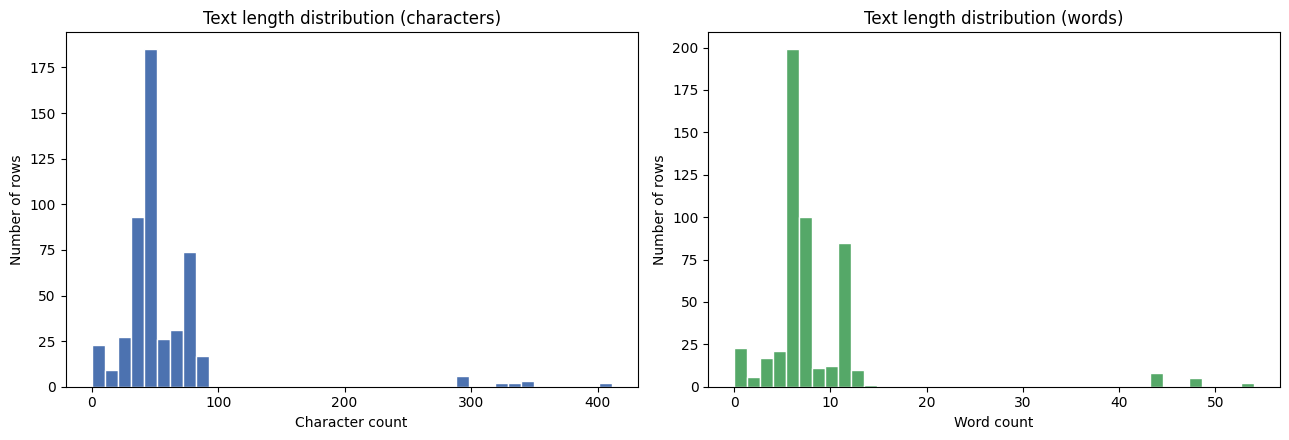


Shortest 10 rows:
      id    text  word_len
28    29                 0
111  112    \t           0
165  166                 0
321  322    \t\t         0
351  352      \t         0
359  360      \n         0
367  368                 0
399  400                 0
436  437                 0
486  487                 0

Longest 10 rows:
      id                                               text  word_len
41    42  The board, after several long and exhausting r...        54
54    55  The committee, after several long and exhausti...        54
43    44  Despite repeated warnings from the safety insp...        48
49    50  Despite repeated warnings from the safety insp...        48
113  114  Despite repeated warnings from the safety insp...        48
304  305  In a sweeping and somewhat rambling statement ...        48
447  448  In a sweeping and somewhat rambling statement ...        48
29    30  The research paper, which had been rejected tw...        44
53    54  After the third round of l

In [ ]:
# ---------------------------------------------------------------------
# CELL 3 — Length distribution (the most important first plot)
# Goal: find length outliers - both very short and very long rows // inspect if any rows are unusually long or short
# ---------------------------------------------------------------------
df_en["char_len"] = df_en["text"].str.len()
df_en["word_len"] = df_en["text"].str.split().apply(len)

print(df_en[["char_len", "word_len"]].describe())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(df_en["char_len"], bins=40, color="#4C72B0", edgecolor="white")
axes[0].set_title("Text length distribution (characters)")
axes[0].set_xlabel("Character count")
axes[0].set_ylabel("Number of rows")

axes[1].hist(df_en["word_len"], bins=40, color="#55A868", edgecolor="white")
axes[1].set_title("Text length distribution (words)")
axes[1].set_xlabel("Word count")
axes[1].set_ylabel("Number of rows")

plt.tight_layout()
plt.show()

# Outliers
print("\nShortest 10 rows:")
print(df_en.nsmallest(10, "word_len")[["id", "text", "word_len"]])

print("\nLongest 10 rows:")
print(df_en.nlargest(10, "word_len")[["id", "text", "word_len"]])


In [ ]:
df_en[["char_len", "word_len"]]

,char_len,word_len
0,73,12
1,46,6
2,46,7
3,39,6
4,81,12
...,...,...
495,42,6
496,41,6
497,48,6
498,51,7


has_url                  :   20 rows (4.0%)
has_mention              :   20 rows (4.0%)
has_hashtag              :   21 rows (4.2%)
has_html_tag             :    9 rows (1.8%)
has_html_entity          :    6 rows (1.2%)
has_emoji                :   20 rows (4.0%)
has_excess_punct         :   12 rows (2.4%)
has_multi_space          :   11 rows (2.2%)
has_tab                  :    6 rows (1.2%)
has_encoding_glitch      :   12 rows (2.4%)


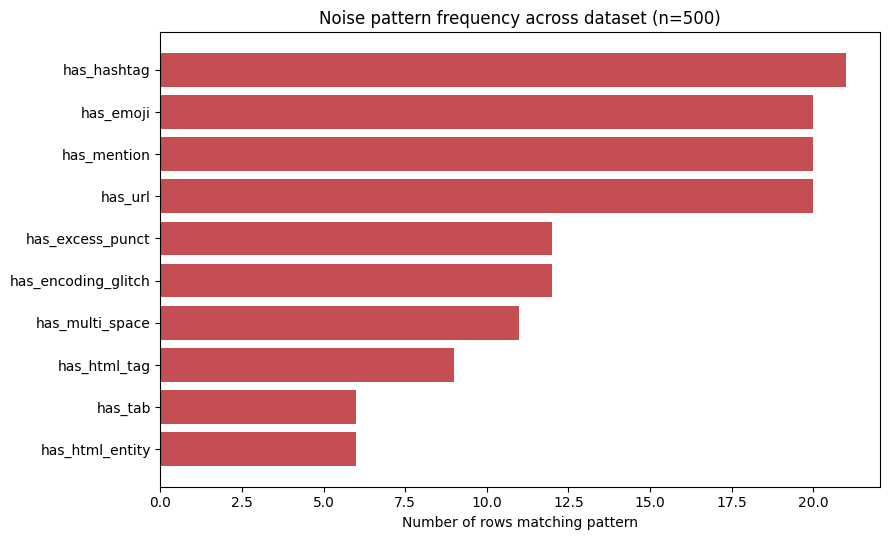

In [ ]:
# =====================================================================
# PART 2 — NOISE ANALYSIS (DIAGNOSTICS)
# Goal: turn "I think there's noise in here" into measurable evidence.
# It ask : does this row contain a URL? Does it contain @mention?
# Does it contain HTML? Does it contain emoji?"
# — and counting how many rows say "yes" to each question.
# Cleaning is not guesswork - it is evidence-driven. Every regex below
# answers one specific question: how much of THIS problem do we have?
# What about the devnagari if present in the sentence, we need to clean that too.
# In that case we can use regex method to find the devnagari wich lies between certain unicode rage just like emojis
# (U+0900 to U+097F)
# =====================================================================

# ---------------------------------------------------------------------
# CELL 4 — Noise pattern detection (regex-based diagnostics)
# Goal: quantify how much of each "messiness" type is actually present
# ---------------------------------------------------------------------
patterns = {
    "has_url": r"https?://\S+|www\.\S+",
    "has_mention": r"@\w+",
    "has_hashtag": r"#\w+",
    "has_html_tag": r"<[^>]+>",
    "has_html_entity": r"&[a-zA-Z]+;",
    "has_emoji": r"[\U0001F300-\U0001FAFF\u2600-\u27BF]",
    "has_excess_punct": r"[!?]{2,}|\.{3,}",
    "has_multi_space": r"  +",
    "has_tab": r"\t",
    "has_encoding_glitch": r"â€|Ã©|Ã¨|Ã¯|Ã¡|â‚¬",
}

counts = {}
for name, pat in patterns.items():
    matches = df_en["text"].str.contains(pat, regex=True, na=False)
    df_en[name] = matches
    counts[name] = matches.sum()
    print(f"{name:25s}: {matches.sum():4d} rows ({matches.mean()*100:.1f}%)")

counts_series = pd.Series(counts).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.barh(counts_series.index, counts_series.values, color="#C44E52")
ax.set_xlabel("Number of rows matching pattern")
ax.set_title(f"Noise pattern frequency across dataset (n={len(df_en)})")
plt.tight_layout()
plt.show()

If you want to drop only @ and # and keep the associated words:

def remove_mentions_hashtags(text):
  
    text = re.sub(r"@(\w+)", r"\1", text)   # mentions: keep the username, drop only '@'

    text = re.sub(r"#(\w+)", r"\1", text)   # hashtags: keep the word, drop only '#'
    return text

In [ ]:
# ---------------------------------------------------------------------
# CELL 5 — Character-level inspection
# Goal: catch stray symbols, non-ASCII characters, hidden artifacts
# ---------------------------------------------------------------------
all_chars = set("".join(df_en["text"].astype(str).tolist()))
non_ascii = sorted([c for c in all_chars if ord(c) > 127])
print(f"Total unique characters: {len(all_chars)}")
print(f"Non-ASCII characters ({len(non_ascii)}): {non_ascii}")

Total unique characters: 111
Non-ASCII characters (28): ['©', '¬', '¯', 'Ã', 'â', 'é', '—', '‚', '“', '”', '€', '™', '☀', '☕', '✨', '❤', '️', '🎉', '🏖', '👏', '🔥', '😂', '😅', '😍', '😡', '😢', '😴', '🙏']


Total tokens: 4156
Vocabulary size: 686
Vocabulary-to-token ratio: 0.165


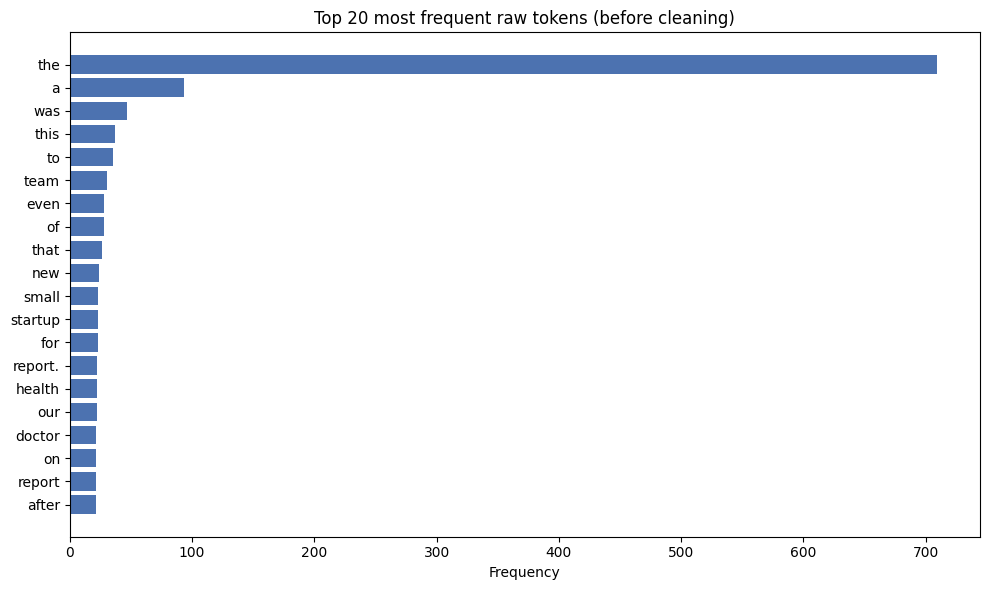


Singleton tokens: 159 (23.2% of vocab)
Sample: ['feedback', '<span', "style='color:red'>warning:", 'server', 'tonight.</span>', 'nope.', 'true.', 'sure.', 'protocol!', 'strategy!', 'cannot', 'this!!!!!!!', 'board,', 'committee,', 'reportâ€™s']


In [ ]:
# ---------------------------------------------------------------------
# CELL 6 [ADVANCED] — Vocabulary and frequency analysis
# Goal: see what's actually common, and whether casing/punctuation
#       is artificially inflating the vocabulary
# ---------------------------------------------------------------------
def naive_tokenize(text):
    return str(text).lower().split()

all_tokens = []
for text in df_en["text"]:
    all_tokens.extend(naive_tokenize(text))

token_counts = Counter(all_tokens)
vocab_size = len(token_counts)
total_tokens = len(all_tokens)

print(f"Total tokens: {total_tokens}")
print(f"Vocabulary size: {vocab_size}")
print(f"Vocabulary-to-token ratio: {vocab_size/total_tokens:.3f}")

top_20 = token_counts.most_common(20)
labels, values = zip(*top_20)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(labels[::-1], values[::-1], color="#4C72B0")
ax.set_xlabel("Frequency")
ax.set_title("Top 20 most frequent raw tokens (before cleaning)")
plt.tight_layout()
plt.show()

# Singleton / long-tail check
singletons = [tok for tok, cnt in token_counts.items() if cnt == 1]
print(f"\nSingleton tokens: {len(singletons)} ({len(singletons)/vocab_size*100:.1f}% of vocab)")
print("Sample:", singletons[:15])

In [ ]:
all_tokens

['a',
 'small',
 'startup',
 'analyzed',
 'the',
 'user',
 'feedback',
 'while',
 'the',
 'data',
 'was',
 'incomplete.',
 'the',
 'government',
 'summarized',
 'the',
 'software',
 'update.',
 'a',
 'local',
 'farmer',
 'questioned',
 'the',
 'software',
 'update.',
 'the',
 'doctor',
 'explained',
 'the',
 'annual',
 'budget.',
 'a',
 'local',
 'farmer',
 'criticized',
 'the',
 'production',
 'schedule',
 'while',
 'the',
 'team',
 'worked',
 'overtime.',
 'the',
 'professor',
 'evaluated',
 'the',
 'construction',
 'plan',
 'while',
 'everyone',
 'agreed',
 'on',
 'the',
 'plan.',
 'my',
 'friend',
 'evaluated',
 'a',
 'detailed',
 'report.',
 'the',
 'doctor',
 'completed',
 'the',
 'construction',
 'plan.',
 'the',
 'scientist',
 'discussed',
 'the',
 'construction',
 'plan.',
 'the',
 'scientist',
 'explained',
 'the',
 'financial',
 'statement',
 'so',
 'that',
 'everyone',
 'agreed',
 'on',
 'the',
 'plan.',
 'the',
 'students',
 'recommended',
 'the',
 'health',
 'guidelines.'

In [ ]:
total_tokens, vocab_size, len(all_tokens), len(token_counts)

(4156, 686, 4156, 686)

# Vocabulary and Frequency Analysis



## Purpose of this step

- Understand how words behave in real text data
- Identify most common and rare words
- Measure vocabulary size and diversity
- Detect noise in raw text
- Understand why simple tokenization is not enough for NLP



## Naive Tokenization (Simple Word Splitting)

We convert text into words using basic rules:

- Convert text to lowercase
- Split text using spaces only



## Example

Input:
"I love NLP"

Output:
i, love, nlp



Input:
"I love NLP!!!"

Output:
i, love, nlp!!!



## Limitation of naive tokenization

- Punctuation stays attached to words
- Does not handle special cases properly
- Fails for:
  - emojis 😢
  - HTML tags <div>
  - URLs https://...



## Vocabulary (Important Concept)

Vocabulary means all unique words in the dataset.

## Example

Input sentences:
I love NLP  
I love AI  

Tokens:
i, love, nlp, i, love, ai  

Vocabulary:
i, love, nlp, ai  


## Token Frequency Analysis

We count how many times each word appears.



## Example

i → 2  
love → 2  
nlp → 1  
ai → 1  



## Why this is useful

- Shows most common words
- Helps identify stopwords like "the", "is", "and"
- Shows rare words in dataset



## Vocabulary Size vs Total Tokens

- Total tokens = all words including repetition
- Vocabulary size = unique words only



## Example

Sentence:
I love NLP I love AI  

Tokens:
i, love, nlp, i, love, ai  

Total tokens = 6  
Vocabulary size = 4  



## Why this matters

- Shows repetition in dataset
- Shows how rich or sparse the language is


## Vocabulary-to-Token Ratio

Formula:
vocabulary size / total tokens



## Interpretation

- Low value → repetitive dataset
- High value → diverse or noisy dataset



## Top Frequent Words

We extract most common words in dataset.



## Example output

the → 500  
is → 300  
nlp → 120  
love → 90  



## Why this is useful

- Shows dominant words in dataset
- Helps identify stopwords
- Helps decide cleaning strategy



## Singleton Analysis (Very Important)



## What is a singleton?

A singleton is a word that appears only once in the entire dataset.



## Example

Sentence:
I love NLP  
I study AI  
I read books  

Tokens:
i, love, nlp, i, study, ai, i, read, books  

Singletons:
nlp, study, ai, read, books  



## Why singletons matter

- They are very rare words
- Often include noise or errors
- Do not help machine learning models learn patterns



## Problems caused by singletons

- Increase vocabulary size unnecessarily
- Make dataset sparse
- Reduce model performance
- Add noise instead of useful information



## Examples from real dataset

- HTML fragments → <span, </div>  
- Punctuation words → protocol!, strategy!  
- Encoding errors → reportâ€™s  
- Broken tokens → tonigh t.</span>  



## Your dataset result

Singleton tokens: 159 (23.2% of vocabulary)

Meaning:

- 159 words appear only once
- Around 23% of vocabulary is rare
- Dataset contains significant noise and sparsity



## Key Insights

- Language data is naturally sparse
- Simple tokenization creates noisy vocabulary
- Many words appear only once
- Cleaning is necessary before modeling
- Advanced tokenization methods are needed later (BPE, WordPiece, SentencePiece)



## Why this step is important

- Helps understand dataset before cleaning
- Shows what type of noise exists
- Explains why vocabulary becomes large
- Builds foundation for modern NLP tokenization

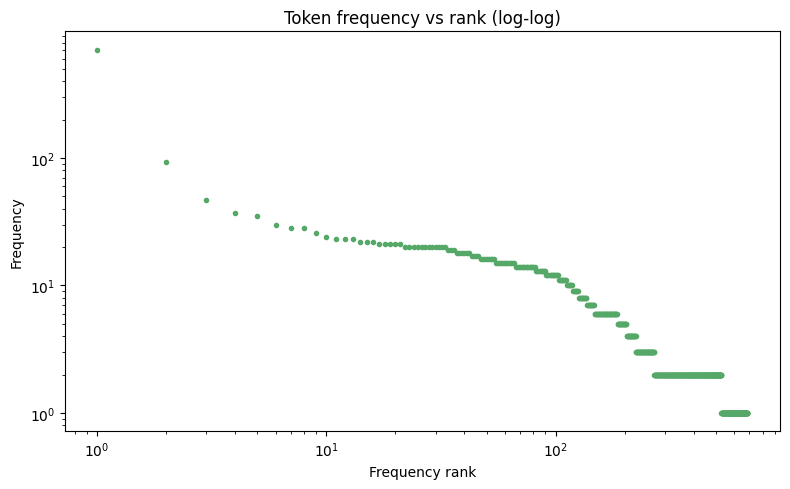

In [ ]:
# ---------------------------------------------------------------------
# CELL 7 [ADVANCED] — Zipf check (frequency vs rank, log-log)
# Goal: visualize the long tail - this is WHY subword tokenization
#       (BPE etc.) exists in modern NLP.
# ---------------------------------------------------------------------
sorted_freqs = sorted(token_counts.values(), reverse=True)
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(1, len(sorted_freqs) + 1), sorted_freqs, marker=".", linestyle="none", color="#55A868")
ax.set_xlabel("Frequency rank")
ax.set_ylabel("Frequency")
ax.set_title("Token frequency vs rank (log-log)")
ax.set_xscale("log")
ax.set_yscale("log")
plt.tight_layout()
plt.show()


# Zipf Check (Frequency vs Rank Analysis)

## Purpose of this Step

The purpose of this analysis is to understand **how words are distributed in a language**.

Instead of studying individual words, we answer a simple question:

> **Do all words appear equally often in a dataset?**

The answer is **No**.

A few words appear very frequently, while thousands of words appear only once or a few times.

This behavior is known as **Zipf's Law**.



## What Does This Code Do?

The code performs the following steps:

- Counts the frequency of every token.
- Sorts the frequencies from highest to lowest.
- Assigns a rank to each frequency.
- Plots **Frequency vs Rank** on a log-log scale.

Notice that we no longer care about **which word** it is. We only care about **how often words occur**.



## Example

Suppose our dataset contains the following word frequencies.

| Word | Frequency |
|------|----------:|
| the | 1200 |
| is | 950 |
| and | 900 |
| AI | 300 |
| learning | 120 |
| transformer | 35 |
| Kathmandu | 3 |
| Subodh | 1 |

After sorting the frequencies in descending order, the words are replaced by their ranks.

| Rank | Frequency |
|------|----------:|
| 1 | 1200 |
| 2 | 950 |
| 3 | 900 |
| 4 | 300 |
| 5 | 120 |
| 6 | 35 |
| 7 | 3 |
| 8 | 1 |



## What Does the Plot Show?

The graph reveals an interesting pattern.

- A small number of words have **very high frequencies**.
- A large number of words have **very low frequencies**.
- Most of the vocabulary lies in the **long tail** of the graph.

This pattern is observed in almost every natural language.



## What is the Long Tail?

The **long tail** represents the large number of words that occur only a few times.

For example,

| Frequency | Number of Words |
|-----------|----------------:|
| 1000+ | 5 |
| 100 | 40 |
| 10 | 600 |
| 1 | 3000 |

This means that although only a few words are extremely common, **most words in a language are actually rare**.


## Why is This Important?

Rare words create several challenges for NLP models.

- The model sees them very few times.
- It cannot learn reliable patterns from them.
- Vocabulary becomes very large.
- The dataset becomes sparse.
- Learning becomes more difficult.



## Connection to Modern Tokenization

This observation explains why modern NLP uses **subword tokenization**.

Instead of treating an entire rare word as a completely new token, it is divided into smaller meaningful pieces.

Example:

**electroencephalography**

↓

electro + encephalo + graphy

These smaller parts appear in many different words, allowing the model to learn them more effectively.

This idea forms the basis of:

- Byte Pair Encoding (BPE)
- WordPiece
- SentencePiece



## Why Use a Log-Log Scale?

Word frequencies vary enormously.

For example,

- the → 120000
- AI → 350
- transformer → 15
- Kathmandu → 2

On a normal graph, small frequencies become almost invisible.

A **log-log scale** compresses very large values while expanding very small values, making the overall distribution much easier to observe.



## Key Insights

- Natural language is **highly unbalanced**.
- A few words occur very frequently.
- Most words occur only once or a few times.
- This phenomenon is known as **Zipf's Law**.
- Rare words increase vocabulary size and sparsity.
- Modern NLP addresses this problem using **subword tokenization** instead of relying only on whole words.

In [ ]:
# ---------------------------------------------------------------------
# CELL 8 [ADVANCED] — Case-variant inflation check
# Goal: quantify how much lowercasing would shrink the vocabulary
# ---------------------------------------------------------------------
raw_vocab = set(t for text in df_en["text"] for t in str(text).split())
lower_vocab = set(t.lower() for text in df_en["text"] for t in str(text).split())

print(f"Vocabulary WITHOUT lowercasing: {len(raw_vocab)}")
print(f"Vocabulary WITH lowercasing:    {len(lower_vocab)}")
print(f"Tokens collapsed by lowercasing: {len(raw_vocab) - len(lower_vocab)}")

Vocabulary WITHOUT lowercasing: 778
Vocabulary WITH lowercasing:    686
Tokens collapsed by lowercasing: 92


In [ ]:
# ---------------------------------------------------------------------
# CELL 9 — Finding -> Action summary table
# ---------------------------------------------------------------------
summary = pd.DataFrame([
    {"Finding": f"{n_empty} empty/whitespace rows", "Cleaning step": "Drop empty rows"},
    {"Finding": f"{n_dup} exact duplicate rows", "Cleaning step": "Deduplicate"},
    {"Finding": f"{counts['has_url']} rows contain URLs", "Cleaning step": "Strip or mask URLs"},
    {"Finding": f"{counts['has_mention']} rows contain @mentions", "Cleaning step": "Strip or mask mentions"},
    {"Finding": f"{counts['has_hashtag']} rows contain #hashtags", "Cleaning step": "Strip or mask hashtags"},
    {"Finding": f"{counts['has_html_tag']} rows contain HTML tags", "Cleaning step": "Strip HTML tags"},
    {"Finding": f"{counts['has_html_entity']} rows contain HTML entities", "Cleaning step": "Decode/strip HTML entities"},
    {"Finding": f"{counts['has_emoji']} rows contain emoji", "Cleaning step": "Decide: keep (signal) or strip (noise)"},
    {"Finding": f"{counts['has_encoding_glitch']} rows show mojibake", "Cleaning step": "Fix encoding (re-decode as UTF-8)"},
    {"Finding": f"{counts['has_multi_space']} rows have irregular whitespace", "Cleaning step": "Normalize whitespace"},
    {"Finding": f"Vocab shrinks by {len(raw_vocab)-len(lower_vocab)} tokens on lowercasing", "Cleaning step": "Lowercase text"},
    {"Finding": f"{len(singletons)} singleton tokens ({len(singletons)/vocab_size*100:.0f}% of vocab)", "Cleaning step": "Consider subword tokenization / spelling normalization"},
])
print(summary.to_string(index=False))

                                  Finding                                          Cleaning step
                 10 empty/whitespace rows                                        Drop empty rows
                  80 exact duplicate rows                                            Deduplicate
                     20 rows contain URLs                                     Strip or mask URLs
                20 rows contain @mentions                                 Strip or mask mentions
                21 rows contain #hashtags                                 Strip or mask hashtags
                 9 rows contain HTML tags                                        Strip HTML tags
             6 rows contain HTML entities                             Decode/strip HTML entities
                    20 rows contain emoji                 Decide: keep (signal) or strip (noise)
                    12 rows show mojibake                      Fix encoding (re-decode as UTF-8)
        11 rows have irregular

In [ ]:
# ---------------------------------------------------------------------
# CELL 10 — Cleaning pipeline blueprint (ordered, decision-stage only)
# Goal: fix the ORDER cleaning steps must run in, and flag which steps
# need a judgment call rather than a fixed rule. Nothing is executed
# here - this is the plan we will implement in Step 3.
# ---------------------------------------------------------------------
cleaning_pipeline_blueprint = [
    {"step": 1, "action": "Fix encoding",            "rule": f"Re-decode mojibake -> {counts['has_encoding_glitch']} rows affected"},
    {"step": 2, "action": "Remove HTML",              "rule": f"Strip tags + decode/strip entities -> {counts['has_html_tag'] + counts['has_html_entity']} rows affected"},
    {"step": 3, "action": "Remove or mask URLs",       "rule": f"{counts['has_url']} rows affected"},
    {"step": 4, "action": "Remove or mask mentions/hashtags", "rule": f"{counts['has_mention']} mentions, {counts['has_hashtag']} hashtags"},
    {"step": 5, "action": "Handle emoji",              "rule": f"DECISION NEEDED: keep (signal) vs strip (noise) -> {counts['has_emoji']} rows affected"},
    {"step": 6, "action": "Normalize whitespace",      "rule": f"Collapse multi-space/tabs -> {counts['has_multi_space'] + counts['has_tab']} rows affected"},
    {"step": 7, "action": "Drop empty rows",           "rule": f"{n_empty} rows affected"},
    {"step": 8, "action": "Deduplicate",               "rule": f"{n_dup} rows affected - run AFTER steps 1-6, since cleaning can reveal new duplicates"},
    {"step": 9, "action": "Lowercase",                 "rule": f"Collapses {len(raw_vocab)-len(lower_vocab)} vocabulary entries"},

]
blueprint_df = pd.DataFrame(cleaning_pipeline_blueprint)
print(blueprint_df.to_string(index=False))

print("""
NOTE on ordering: steps 1-6 must run BEFORE deduplication (step 8),
because two rows that look different before cleaning (e.g. one with
a tracking URL, one without) can become identical AFTER cleaning -
those are the duplicates that matter most to catch.
""")

 step                           action                                                                             rule
    1                     Fix encoding                                           Re-decode mojibake -> 12 rows affected
    2                      Remove HTML                           Strip tags + decode/strip entities -> 15 rows affected
    3              Remove or mask URLs                                                                 20 rows affected
    4 Remove or mask mentions/hashtags                                                         20 mentions, 21 hashtags
    5                     Handle emoji              DECISION NEEDED: keep (signal) vs strip (noise) -> 20 rows affected
    6             Normalize whitespace                                    Collapse multi-space/tabs -> 17 rows affected
    7                  Drop empty rows                                                                 10 rows affected
    8                      Deduplicate 8

# Cleaning

In [ ]:
# ---------------------------------------------------------------------
# CELL 11 — Cleaning pipeline IMPLEMENTATION
# Goal: actually execute the blueprint from Cell 10, in the same order,
# and show a before/after comparison so the effect of cleaning is
# visible and measurable - not just assumed.
# ---------------------------------------------------------------------
import re
import html as html_lib

# ---- Step 1: Fix encoding (mojibake) ----
MOJIBAKE_MAP = {
    "â€™": "'", "â€˜": "'", "â€œ": '"', "â€\x9d": '"',
    "â€“": "-", "â€”": "-", "â€¦": "...", "â‚¬": "EUR",
    "Ã©": "e", "Ã¨": "e", "Ã¯": "i", "Ã¡": "a",
}
def fix_encoding(text):
    text = str(text)
    for bad, good in MOJIBAKE_MAP.items():
        text = text.replace(bad, good)
    return text

# ---- Step 2: Remove HTML (tags + entities) ----
def remove_html(text):
    text = re.sub(r"<[^>]+>", " ", text)
    text = html_lib.unescape(text)
    return text

# ---- Step 3: Remove or mask URLs ----
def remove_urls(text):
    return re.sub(r"https?://\S+|www\.\S+", " ", text)

# ---- Step 4: Remove or mask mentions/hashtags ----
def remove_mentions_hashtags(text):
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"#\w+", " ", text)
    return text

# ---- Step 5: Handle emoji [DECISION: stripping here; flip KEEP_EMOJI to keep them] ----
KEEP_EMOJI = False  # <-- the judgment call flagged in the blueprint
def handle_emoji(text):
    if KEEP_EMOJI:
        return text
    return re.sub(r"[\U0001F300-\U0001FAFF\u2600-\u27BF]", " ", text)

# ---- Step 6: Normalize whitespace ----
def normalize_whitespace(text):
    text = text.replace("\t", " ")
    text = re.sub(r" +", " ", text)
    return text.strip()

def clean_text(text):
    text = fix_encoding(text)
    text = remove_html(text)
    text = remove_urls(text)
    text = remove_mentions_hashtags(text)
    text = handle_emoji(text)
    text = normalize_whitespace(text)
    return text

# APPLY steps 1-6
df_en["text_clean"] = df_en["text"].apply(clean_text)

# Step 7: Drop empty rows (AFTER cleaning)
n_before = len(df_en)
df_en_clean = df_en[df_en["text_clean"].str.strip() != ""].copy()
n_after_empty_drop = len(df_en_clean)

# Step 8: Deduplicate (AFTER cleaning)
n_before_dedup = len(df_en_clean)
df_en_clean = df_en_clean.drop_duplicates(subset="text_clean").copy()
n_after_dedup = len(df_en_clean)

# Step 9: Lowercase
df_en_clean["text_clean"] = df_en_clean["text_clean"].str.lower()

# SUMMARY
print(f"Rows before cleaning:                {n_before}")
print(f"Rows after dropping empty (step 7):   {n_after_empty_drop}  ({n_before - n_after_empty_drop} dropped)")
print(f"Rows after deduplication (step 8):    {n_after_dedup}  ({n_before_dedup - n_after_dedup} dropped)")
print(f"Final cleaned row count:              {len(df_en_clean)}")

print("\nSample BEFORE -> AFTER (5 rows that changed the most):")
df_en["_len_before"] = df_en["text"].str.len()
df_en["_len_after"] = df_en["text_clean"].str.len()
df_en["_len_diff"] = df_en["_len_before"] - df_en["_len_after"]
sample = df_en.nlargest(5, "_len_diff")[["text", "text_clean"]]
for _, row in sample.iterrows():
    print(f"\nBEFORE: {row['text']}")
    print(f"AFTER:  {row['text_clean']}")

raw_vocab_check = set(t for text in df_en["text"] for t in str(text).split())
clean_vocab_check = set(t for text in df_en_clean["text_clean"] for t in str(text).split())
print(f"\nVocabulary BEFORE: {len(raw_vocab_check)}  |  AFTER: {len(clean_vocab_check)}  |  "
      f"Reduction: {len(raw_vocab_check)-len(clean_vocab_check)} ({(len(raw_vocab_check)-len(clean_vocab_check))/len(raw_vocab_check)*100:.1f}%)")

Rows before cleaning:                500
Rows after dropping empty (step 7):   489  (11 dropped)
Rows after deduplication (step 8):    413  (76 dropped)
Final cleaned row count:              413

Sample BEFORE -> AFTER (5 rows that changed the most):

BEFORE: The dataset is hosted at http://data.example.org/downloads/dataset.csv
AFTER:  The dataset is hosted at

BEFORE: The dataset is hosted at http://data.example.org/downloads/dataset.csv
AFTER:  The dataset is hosted at

BEFORE: Great talk by @sarah_lee today on #machinelearning and #datascience
AFTER:  Great talk by today on and

BEFORE: Great talk by @sarah_lee today on #machinelearning and #datascience
AFTER:  Great talk by today on and

BEFORE: Original source: https://news.example.com/world/story123
AFTER:  Original source:

Vocabulary BEFORE: 778  |  AFTER: 624  |  Reduction: 154 (19.8%)


In [ ]:
# =====================================================================
# Tokenization
# =====================================================================
#Stemming/lemmatization (optional)
#Numericalization
#Embedding
#Modelling

**Tokenization**, the first stage of natural language processing, is the process of
segmenting the running input text into tokens. Here, tokens may be whole words,
morphemes, or subword pieces in general, down to individual characters in the
extreme case — and they may or may not correspond to meaningful linguistic units.
The tokenizer cuts based on its own rules or learned statistics, not on whether
the resulting piece carries meaning on its own.




1.  Whitespace tokenization
2.  Rule-based / regex tokenization
3.  Character-level tokenization
4.  Morpheme-based tokenization
5.  Byte-Pair Encoding (BPE)



